In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [73]:
df = pd.read_csv("/content/stroke_data_sprint1_final.csv")

In [74]:
print("Dataset shape:", df.shape)

Dataset shape: (5110, 12)


# 1. Descriptive Analysis

Numerical Features

In [75]:
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()

print("Numerical Features:")
print(numerical_columns)

Numerical Features:
['id', 'age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke']


Summary Statistics

In [76]:
df[numerical_columns].describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.862035,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.699562,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.800000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,32.800000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


Measures of Central Tendency

In [77]:
central_tendency = pd.DataFrame({
    "Mean": df[numerical_columns].mean(),
    "Median": df[numerical_columns].median(),
    "Mode": df[numerical_columns].mode().iloc[0]
})

central_tendency

,Mean,Median,Mode
id,36517.829354,36932.000,67.00
age,43.226614,45.000,78.00
hypertension,0.097456,0.000,0.00
heart_disease,0.054012,0.000,0.00
avg_glucose_level,106.147677,91.885,93.88
bmi,28.862035,28.100,28.10
stroke,0.048728,0.000,0.00


Measures of Dispersion

In [78]:
dispersion = pd.DataFrame({
    "Range": df[numerical_columns].max() - df[numerical_columns].min(),
    "Variance": df[numerical_columns].var(),
    "Standard Deviation": df[numerical_columns].std()
})

dispersion

,Range,Variance,Standard Deviation
id,72873.00,4.478185e+08,21161.721625
age,81.92,5.113318e+02,22.612647
hypertension,1.00,8.797552e-02,0.296607
heart_disease,1.00,5.110447e-02,0.226063
avg_glucose_level,216.62,2.050601e+03,45.283560
bmi,87.30,5.928326e+01,7.699562
stroke,1.00,4.636264e-02,0.215320


Observation  :      


 - Age has a relatively wide range because the dataset contains patients from very young ages to 82 years.

 - Average glucose level also has considerable variation.

 - BMI has less variation compared with age and glucose level, although some high BMI values are present.

Skewness

In [79]:
skewness = df[["age", "avg_glucose_level", "bmi"]].skew()

print(skewness)

age                 -0.137059
avg_glucose_level    1.572284
bmi                  1.088187
dtype: float64


Observation   :    


 - Age is approximately symmetric with a slight negative skew.

 - Average glucose level is positively skewed, meaning that some patients have considerably higher glucose levels.

 - BMI is also positively skewed because of some higher BMI observations.

# 2. Univariate Analysis

Numerical Variable Distribution

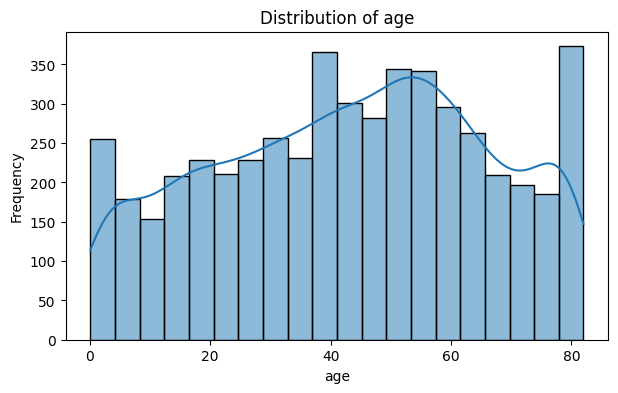

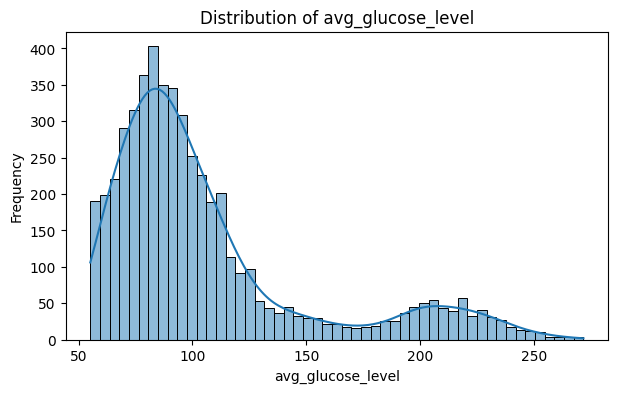

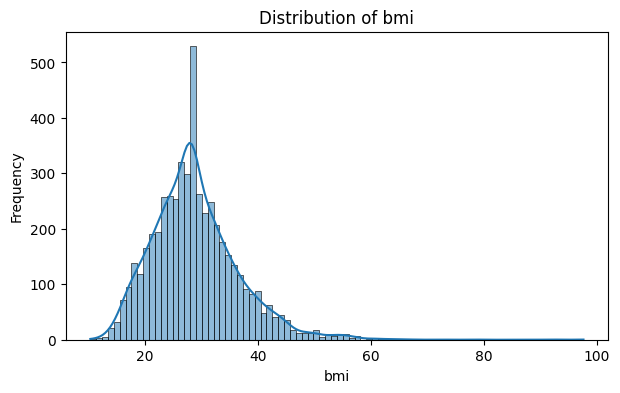

In [80]:
numerical_for_distribution = [
    "age",
    "avg_glucose_level",
    "bmi"
]

for column in numerical_for_distribution:
    plt.figure(figsize=(7, 4))
    sns.histplot(data=df, x=column, kde=True)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

Observation  :    


 - Age is distributed across a wide range of patients.

 - Average glucose level shows a right-skewed distribution with a number of patients having higher glucose levels.

 - BMI is also right-skewed, with most values concentrated around the middle range and fewer very high values.

Numerical Variable Box Plots

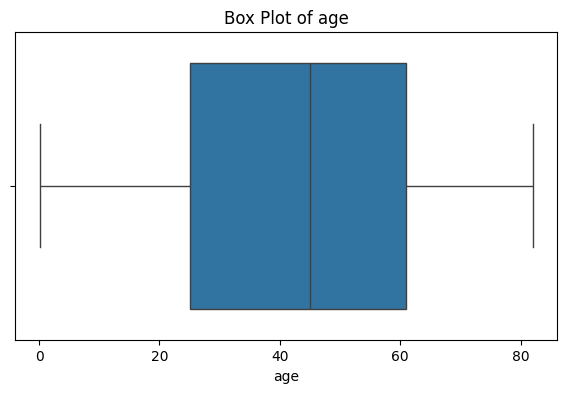

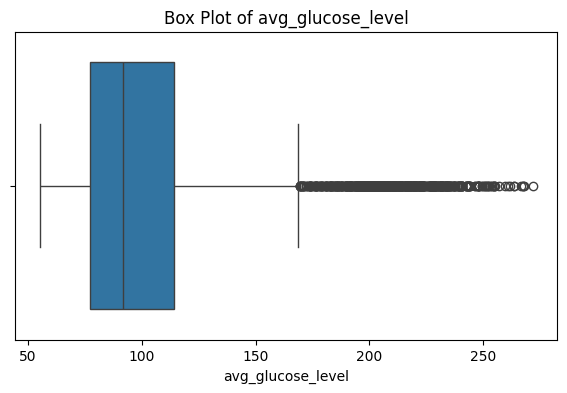

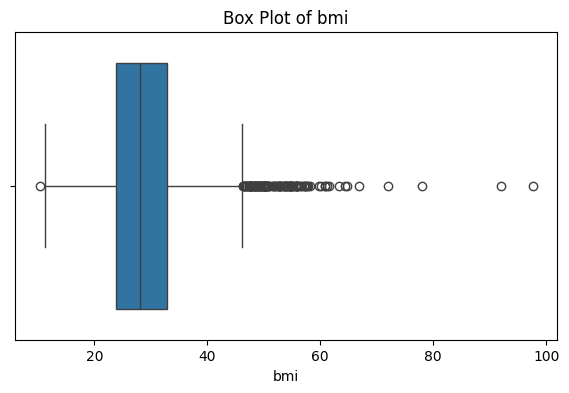

In [81]:
for column in numerical_for_distribution:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x=df[column])
    plt.title(f"Box Plot of {column}")
    plt.xlabel(column)
    plt.show()

Outlier Counts

In [82]:
outlier_results = []

for column in numerical_for_distribution:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((df[column] < lower) | (df[column] > upper)).sum()

    outlier_results.append([column, count])

outlier_results = pd.DataFrame(
    outlier_results,
    columns=["Feature", "Outlier Count"]
)

outlier_results

,Feature,Outlier Count
0,age,0
1,avg_glucose_level,627
2,bmi,126


Observation  :    




 - No IQR outliers were identified in age.

 - Average glucose level has a noticeable number of outliers.

 - BMI also contains some outlier values.

 - These values are not automatically removed because they can represent genuine patient conditions.

Categorical Variable Analysis

In [83]:
categorical_columns = df.select_dtypes(include="object").columns.tolist()

print(categorical_columns)

['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']


Gender

In [84]:
print(df["gender"].value_counts())

gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64


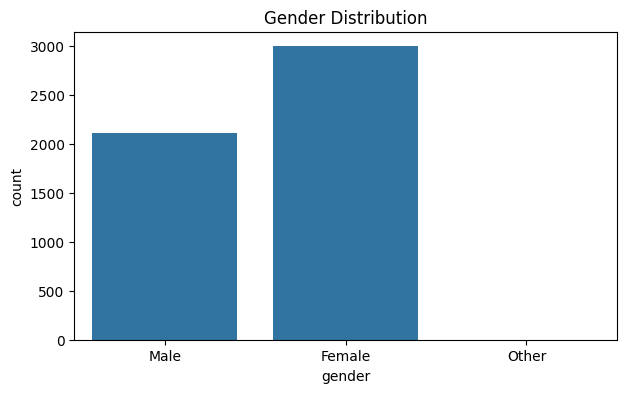

In [85]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="gender")
plt.title("Gender Distribution")
plt.show()

Observation  :    


 - Female patients form the largest group, followed by male patients. Only one record belongs to the Other category.

Marital Status

In [86]:
print(df["ever_married"].value_counts())

ever_married
Yes    3353
No     1757
Name: count, dtype: int64


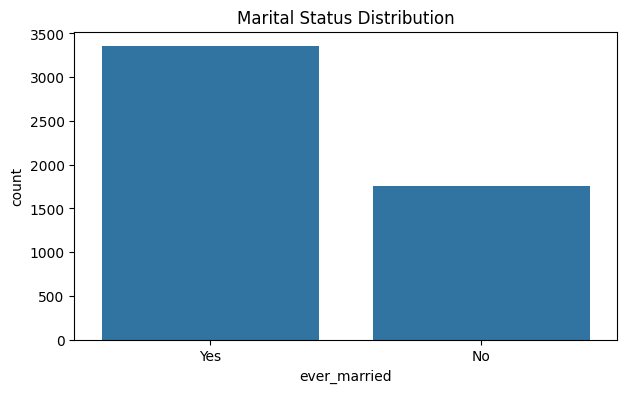

In [87]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="ever_married")
plt.title("Marital Status Distribution")
plt.show()

Work Type

In [88]:
print(df["work_type"].value_counts())

work_type
Private          2925
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64


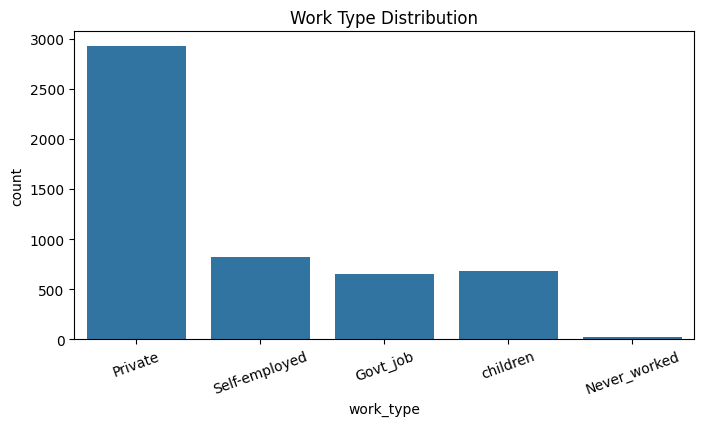

In [89]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="work_type")
plt.xticks(rotation=20)
plt.title("Work Type Distribution")
plt.show()

Residence Type

In [90]:
print(df["Residence_type"].value_counts())

Residence_type
Urban    2596
Rural    2514
Name: count, dtype: int64


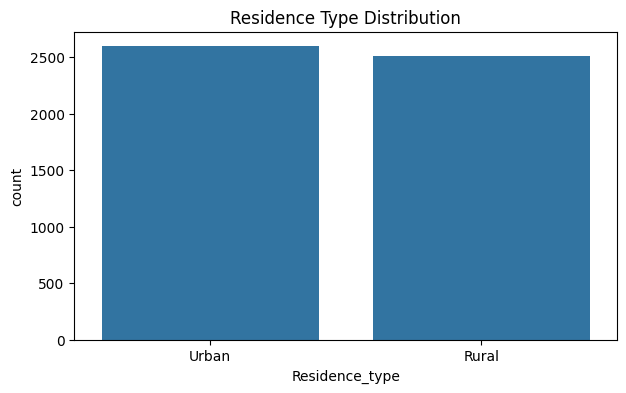

In [91]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="Residence_type")
plt.title("Residence Type Distribution")
plt.show()

Smoking Status

In [92]:
print(df["smoking_status"].value_counts())

smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64


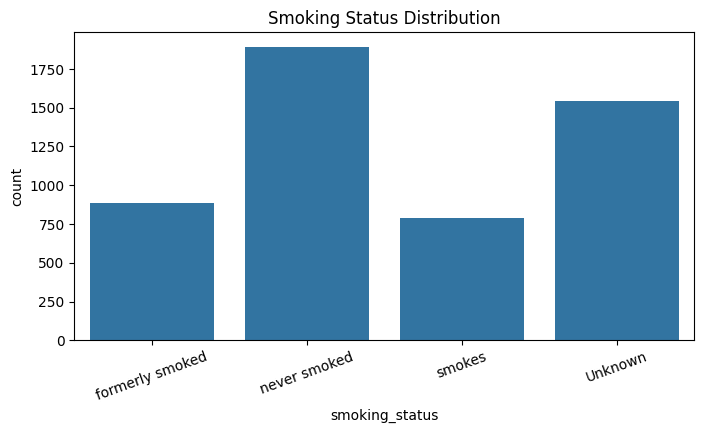

In [93]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="smoking_status")
plt.xticks(rotation=20)
plt.title("Smoking Status Distribution")
plt.show()

Stroke Class Imbalance

In [94]:
stroke_counts = df["stroke"].value_counts()

print(stroke_counts)

stroke
0    4861
1     249
Name: count, dtype: int64


In [95]:
stroke_percentage = df["stroke"].value_counts(normalize=True) * 100

print(stroke_percentage)

stroke
0    95.127202
1     4.872798
Name: proportion, dtype: float64


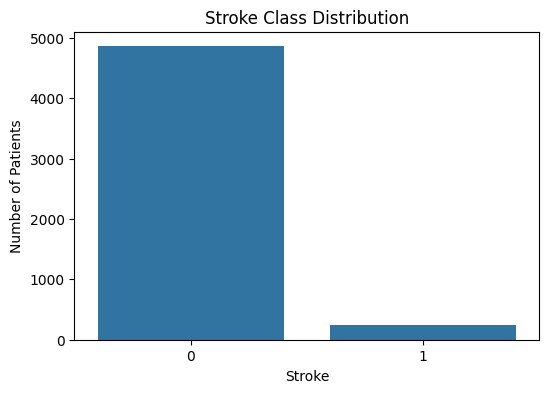

In [96]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="stroke")
plt.title("Stroke Class Distribution")
plt.xlabel("Stroke")
plt.ylabel("Number of Patients")
plt.show()

Observation :    


 - The target variable is highly imbalanced.

 - Approximately 95.13% of patients did not experience a stroke, while only 4.87% experienced a stroke.

 - This means that stroke cases are much fewer than non-stroke cases and this should be considered when interpreting the analysis.

# 3. Bivariate Analysis

Numerical vs Numerical

Age vs Average Glucose

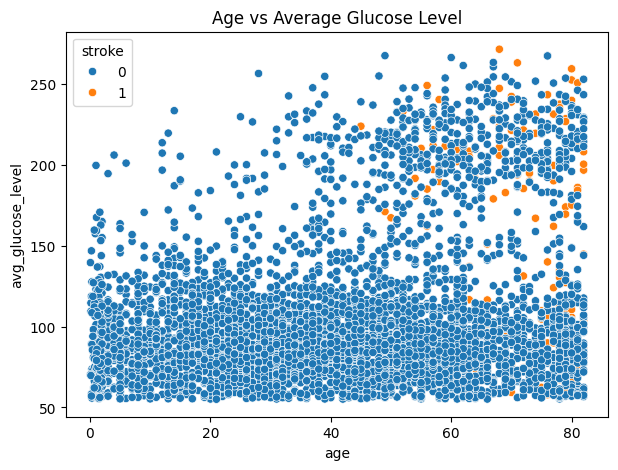

In [97]:
plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df,
    x="age",
    y="avg_glucose_level",
    hue="stroke"
)

plt.title("Age vs Average Glucose Level")
plt.show()

Observation  :    


 - The scatter plot shows that patients are spread across different age and glucose levels. Stroke cases are more visible among older patients, and several stroke cases also occur at higher glucose levels.

Age vs BMI

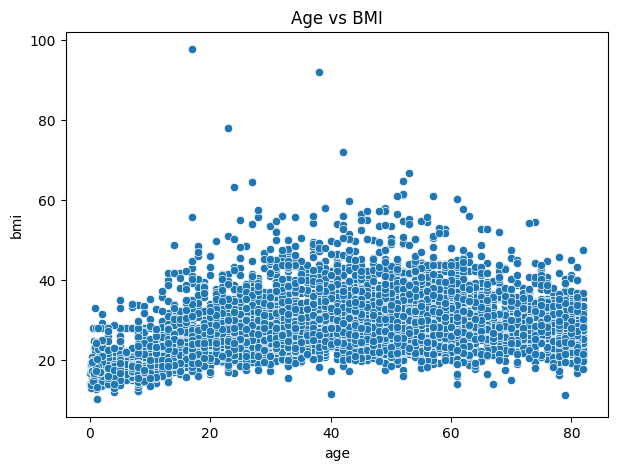

In [98]:
plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df,
    x="age",
    y="bmi"
)

plt.title("Age vs BMI")
plt.show()

Numerical vs Categorical

Age vs Stroke

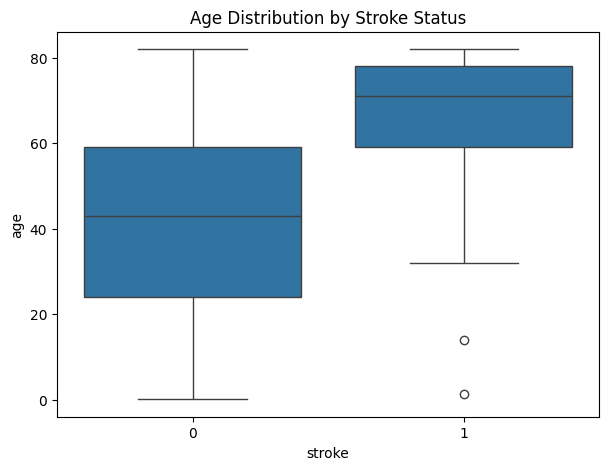

In [99]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="stroke",
    y="age"
)

plt.title("Age Distribution by Stroke Status")
plt.show()

In [100]:
df.groupby("stroke")["age"].mean()

,age
stroke,
0,41.971545
1,67.728193


Observation  :     


 - The average age of patients who experienced a stroke is much higher than the average age of patients who did not experience a stroke.

 - This suggests that age is an important variable to consider when studying stroke occurrence.

Glucose vs Stroke

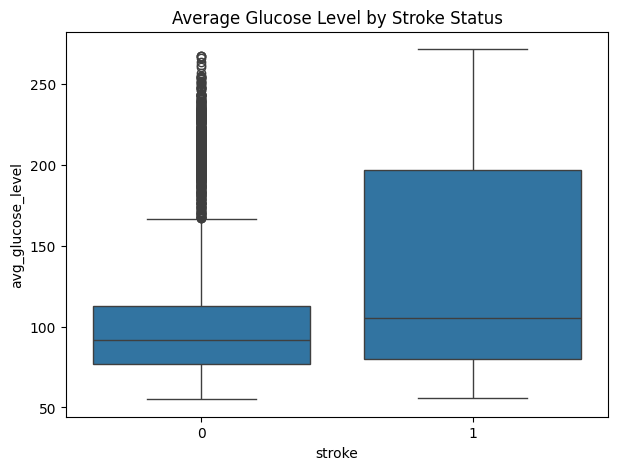

In [101]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="stroke",
    y="avg_glucose_level"
)

plt.title("Average Glucose Level by Stroke Status")
plt.show()

In [102]:
df.groupby("stroke")["avg_glucose_level"].mean()

,avg_glucose_level
stroke,
0,104.795513
1,132.544739


Observation  :    


 - Patients with stroke have a higher average glucose level than patients without stroke.

BMI vs Stroke

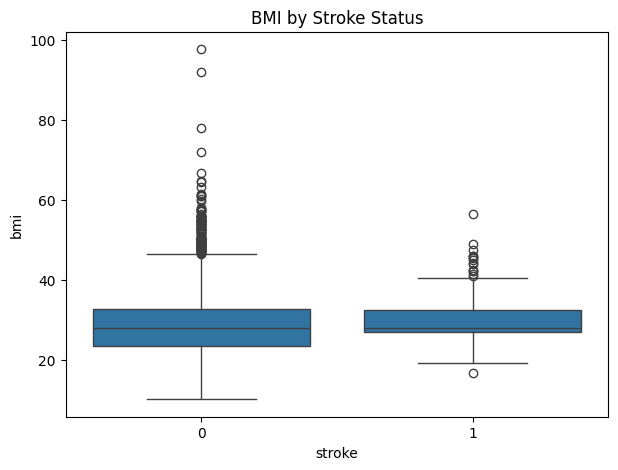

In [103]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="stroke",
    y="bmi"
)

plt.title("BMI by Stroke Status")
plt.show()

Categorical vs Categorical

Gender vs Stroke

In [104]:
gender_stroke = pd.crosstab(
    df["gender"],
    df["stroke"],
    normalize="index"
) * 100

gender_stroke

stroke,0,1
gender,,
Female,95.290581,4.709419
Male,94.893617,5.106383
Other,100.000000,0.000000


Work Type vs Stroke

In [105]:
work_stroke = pd.crosstab(
    df["work_type"],
    df["stroke"],
    normalize="index"
) * 100

work_stroke

stroke,0,1
work_type,,
Govt_job,94.977169,5.022831
Never_worked,100.000000,0.000000
Private,94.905983,5.094017
Self-employed,92.063492,7.936508
children,99.708879,0.291121


Smoking Status vs Stroke

In [106]:
smoking_stroke = pd.crosstab(
    df["smoking_status"],
    df["stroke"],
    normalize="index"
) * 100

smoking_stroke

stroke,0,1
smoking_status,,
Unknown,96.955959,3.044041
formerly smoked,92.090395,7.909605
never smoked,95.243129,4.756871
smokes,94.676806,5.323194


Observation  :    


 - Stroke occurrence differs across categorical groups.

 - Self-employed patients show a higher stroke percentage than several other work groups.

 - Patients who formerly smoked also show a higher stroke percentage than the never-smoked group.

 - These differences show patterns in the dataset, but they should not be treated as proof that a category directly causes stroke.

# 4. Multivariate Analysis

Pair Plot

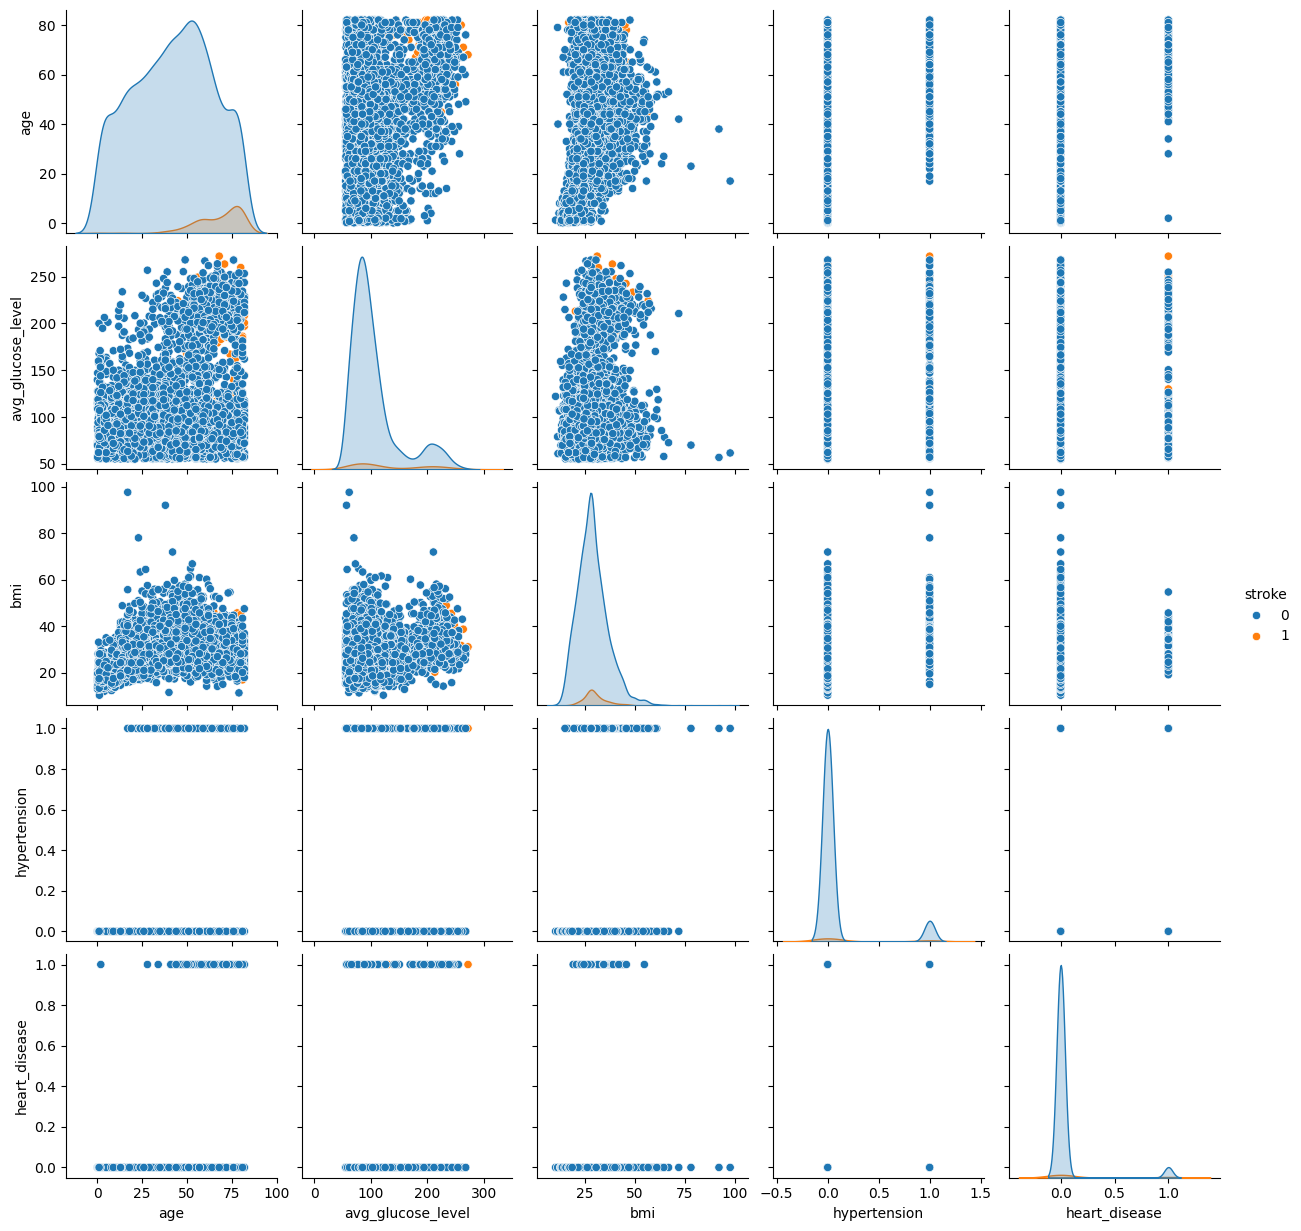

In [107]:
sns.pairplot(
    df[[
        "age",
        "avg_glucose_level",
        "bmi",
        "hypertension",
        "heart_disease",
        "stroke"
    ]],
    hue="stroke"
)

plt.show()

Observation  :    


 - The multivariate view shows that stroke cases tend to be more visible among older patients and among patients with higher glucose levels. Hypertension and heart disease are also more common among stroke cases.

Combined Health Factors

In [108]:
health_summary = df.groupby("stroke")[
    [
        "age",
        "avg_glucose_level",
        "bmi",
        "hypertension",
        "heart_disease"
    ]
].mean()

health_summary

,age,avg_glucose_level,bmi,hypertension,heart_disease
stroke,,,,,
0,41.971545,104.795513,28.799115,0.088871,0.047110
1,67.728193,132.544739,30.090361,0.265060,0.188755


Observation  :     


 - When multiple health variables are considered together, stroke patients in this dataset have higher average age and glucose levels and higher average hypertension and heart disease indicators.

 - This suggests that stroke occurrence is associated with a combination of patient characteristics rather than one variable alone.

# 5. Group-Based Analysis

Stroke by Gender

In [109]:
gender_analysis = df.groupby("gender").agg(
    Patients=("stroke", "count"),
    Stroke_Cases=("stroke", "sum"),
    Stroke_Rate=("stroke", "mean")
)

gender_analysis["Stroke_Rate"] *= 100

gender_analysis

,Patients,Stroke_Cases,Stroke_Rate
gender,,,
Female,2994,141,4.709419
Male,2115,108,5.106383
Other,1,0,0.000000


Stroke by Work Type

In [110]:
work_analysis = df.groupby("work_type").agg(
    Patients=("stroke", "count"),
    Stroke_Cases=("stroke", "sum"),
    Stroke_Rate=("stroke", "mean"),
    Average_Age=("age", "mean"),
    Average_Glucose=("avg_glucose_level", "mean")
)

work_analysis["Stroke_Rate"] *= 100

work_analysis

,Patients,Stroke_Cases,Stroke_Rate,Average_Age,Average_Glucose
work_type,,,,,
Govt_job,657,33,5.022831,50.879756,107.779772
Never_worked,22,0,0.000000,16.181818,96.042727
Private,2925,149,5.094017,45.503932,106.796844
Self-employed,819,65,7.936508,60.201465,112.645446
children,687,2,0.291121,6.841339,94.400277


Stroke by Smoking Status

In [111]:
smoking_analysis = df.groupby("smoking_status").agg(
    Patients=("stroke", "count"),
    Stroke_Cases=("stroke", "sum"),
    Stroke_Rate=("stroke", "mean")
)

smoking_analysis["Stroke_Rate"] *= 100

smoking_analysis

,Patients,Stroke_Cases,Stroke_Rate
smoking_status,,,
Unknown,1544,47,3.044041
formerly smoked,885,70,7.909605
never smoked,1892,90,4.756871
smokes,789,42,5.323194


Stroke by Hypertension

In [112]:
hypertension_analysis = df.groupby("hypertension").agg(
    Patients=("stroke", "count"),
    Stroke_Cases=("stroke", "sum"),
    Stroke_Rate=("stroke", "mean")
)

hypertension_analysis["Stroke_Rate"] *= 100

hypertension_analysis

,Patients,Stroke_Cases,Stroke_Rate
hypertension,,,
0,4612,183,3.967910
1,498,66,13.253012


Observation  :     


 - Patients with hypertension have a considerably higher stroke rate than patients without hypertension.

Stroke by Heart Disease

In [113]:
heart_analysis = df.groupby("heart_disease").agg(
    Patients=("stroke", "count"),
    Stroke_Cases=("stroke", "sum"),
    Stroke_Rate=("stroke", "mean")
)

heart_analysis["Stroke_Rate"] *= 100

heart_analysis

,Patients,Stroke_Cases,Stroke_Rate
heart_disease,,,
0,4834,202,4.178734
1,276,47,17.028986


Observation   :     




 - The stroke rate is considerably higher among patients with heart disease in this dataset.

# 6. Pivot Table Analysis

Pivot Table 1 — Stroke by Gender

In [114]:
pivot_gender = pd.pivot_table(
    df,
    index="gender",
    columns="stroke",
    values="age",
    aggfunc="count",
    fill_value=0
)

pivot_gender

stroke,0,1
gender,,
Female,2853,141
Male,2007,108
Other,1,0


Pivot Table 2 — Work Type and Stroke

In [115]:
pivot_work = pd.pivot_table(
    df,
    index="work_type",
    columns="stroke",
    values="age",
    aggfunc="count",
    fill_value=0
)

pivot_work

stroke,0,1
work_type,,
Govt_job,624,33
Never_worked,22,0
Private,2776,149
Self-employed,754,65
children,685,2


Pivot Table 3 — Smoking Status and Stroke

In [116]:
pivot_smoking = pd.pivot_table(
    df,
    index="smoking_status",
    columns="stroke",
    values="age",
    aggfunc="count",
    fill_value=0
)

pivot_smoking

stroke,0,1
smoking_status,,
Unknown,1497,47
formerly smoked,815,70
never smoked,1802,90
smokes,747,42


Pivot Table 4 — Hypertension and Heart Disease

In [117]:
pivot_health = pd.pivot_table(
    df,
    index="hypertension",
    columns="heart_disease",
    values="stroke",
    aggfunc=["count", "sum"],
    fill_value=0
)

pivot_health

count       sum    
heart_disease     0    1    0   1
hypertension                     
0              4400  212  149  34
1               434   64   53  13

Observation  :     


 - The pivot tables show that stroke cases are distributed differently across demographic, lifestyle and health groups.

 - The health-related pivot table is particularly useful because it allows hypertension and heart disease to be viewed together instead of separately.

 - This helps identify groups that may require closer attention in further analysis.

# 7. Crosstab Analysis

Gender vs Stroke

In [118]:
pd.crosstab(
    df["gender"],
    df["stroke"],
    margins=True
)

stroke,0,1,All
gender,,,
Female,2853,141,2994
Male,2007,108,2115
Other,1,0,1
All,4861,249,5110


Hypertension vs Stroke

In [119]:
pd.crosstab(
    df["hypertension"],
    df["stroke"],
    margins=True
)

stroke,0,1,All
hypertension,,,
0,4429,183,4612
1,432,66,498
All,4861,249,5110


Heart Disease vs Stroke

In [120]:
pd.crosstab(
    df["heart_disease"],
    df["stroke"],
    margins=True
)

stroke,0,1,All
heart_disease,,,
0,4632,202,4834
1,229,47,276
All,4861,249,5110


Smoking Status vs Stroke

In [121]:
pd.crosstab(
    df["smoking_status"],
    df["stroke"],
    margins=True
)

stroke,0,1,All
smoking_status,,,
Unknown,1497,47,1544
formerly smoked,815,70,885
never smoked,1802,90,1892
smokes,747,42,789
All,4861,249,5110


Work Type vs Stroke

In [122]:
pd.crosstab(
    df["work_type"],
    df["stroke"],
    margins=True
)

stroke,0,1,All
work_type,,,
Govt_job,624,33,657
Never_worked,22,0,22
Private,2776,149,2925
Self-employed,754,65,819
children,685,2,687
All,4861,249,5110


Observation  :    


 - The crosstab analysis shows that stroke cases are not evenly distributed across all categories.

 - The strongest differences in stroke proportions are visible for health-related variables such as hypertension and heart disease.

 - Smoking status and work type also show differences between groups, although these differences should be interpreted carefully.

# 8. Correlation & Relationship Analysis

Correlation Matrix

In [123]:
correlation_matrix = df[
    [
        "age",
        "hypertension",
        "heart_disease",
        "avg_glucose_level",
        "bmi",
        "stroke"
    ]
].corr()

correlation_matrix

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
age,1.000000,0.276398,0.263796,0.238171,0.324296,0.245257
hypertension,0.276398,1.000000,0.108306,0.174474,0.158293,0.127904
heart_disease,0.263796,0.108306,1.000000,0.161857,0.036916,0.134914
avg_glucose_level,0.238171,0.174474,0.161857,1.000000,0.166876,0.131945
bmi,0.324296,0.158293,0.036916,0.166876,1.000000,0.036110
stroke,0.245257,0.127904,0.134914,0.131945,0.036110,1.000000


Correlation with Stroke

In [124]:
stroke_correlation = correlation_matrix["stroke"].sort_values(
    ascending=False
)

stroke_correlation

,stroke
stroke,1.000000
age,0.245257
heart_disease,0.134914
avg_glucose_level,0.131945
hypertension,0.127904
bmi,0.036110


Interpretation  :     


 - Age has the strongest positive correlation with stroke among the numerical variables, although the correlation is still moderate rather than strong.

 - Heart disease, average glucose level and hypertension have weak positive correlations with stroke.

 - BMI has a very weak positive correlation with stroke.

 - No strong negative correlation with stroke is observed among these numerical variables.

Correlation Heatmap

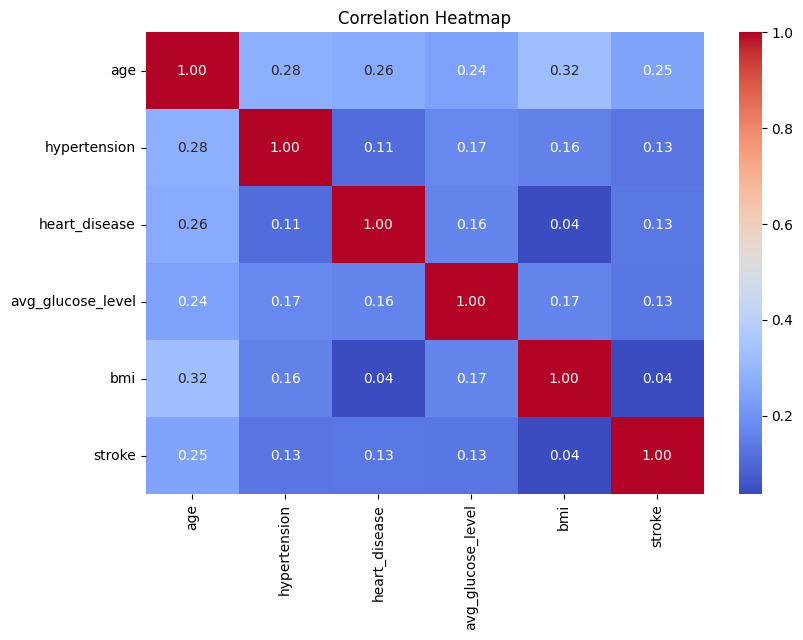

In [125]:
plt.figure(figsize=(9, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

Observation  :      


 - The heatmap shows that age has the highest positive numerical relationship with stroke in this dataset. Heart disease, glucose level and hypertension also have positive relationships, while BMI has a much weaker relationship.

# 9. Data Visualization

Histogram

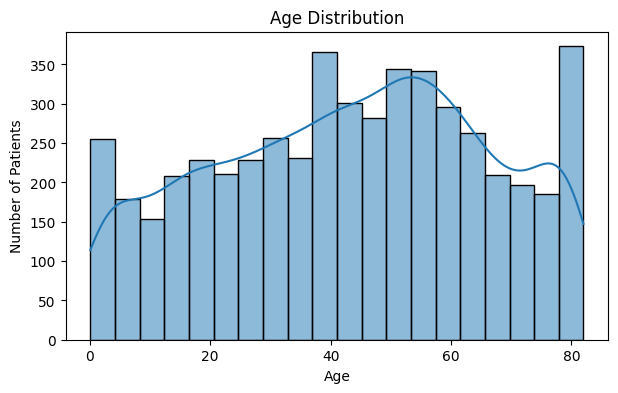

In [126]:
plt.figure(figsize=(7, 4))

sns.histplot(
    data=df,
    x="age",
    kde=True
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.show()

Count Plot

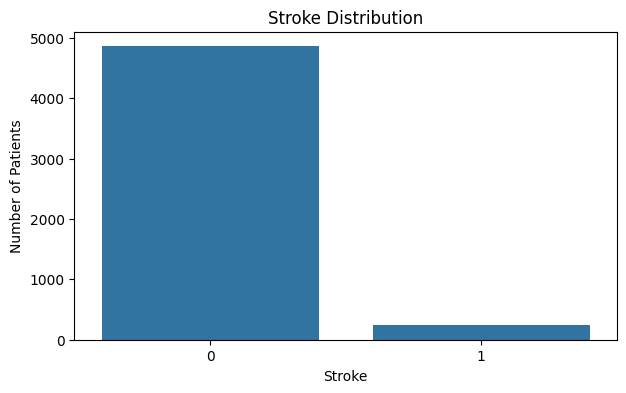

In [127]:
plt.figure(figsize=(7, 4))

sns.countplot(
    data=df,
    x="stroke"
)

plt.title("Stroke Distribution")
plt.xlabel("Stroke")
plt.ylabel("Number of Patients")
plt.show()

Box Plot

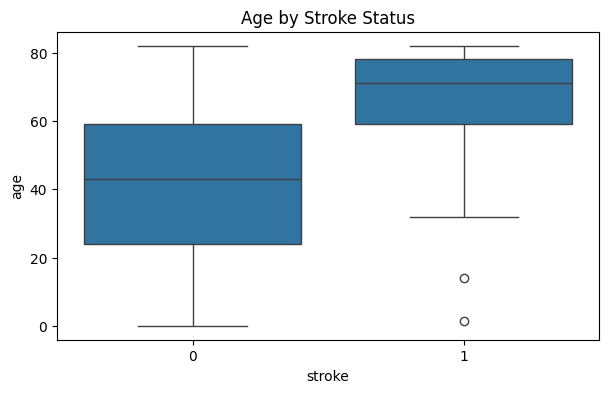

In [128]:
plt.figure(figsize=(7, 4))

sns.boxplot(
    data=df,
    x="stroke",
    y="age"
)

plt.title("Age by Stroke Status")
plt.show()

Violin Plot

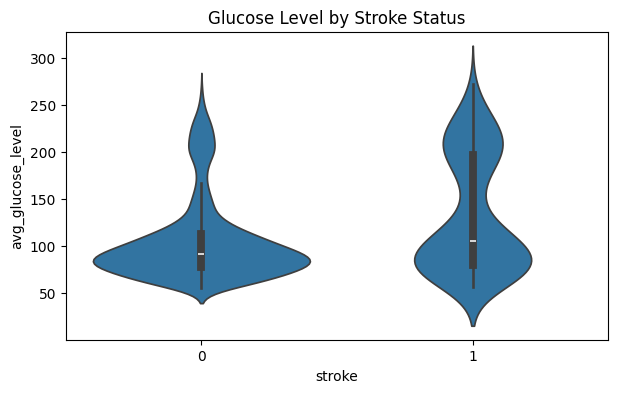

In [129]:
plt.figure(figsize=(7, 4))

sns.violinplot(
    data=df,
    x="stroke",
    y="avg_glucose_level"
)

plt.title("Glucose Level by Stroke Status")
plt.show()

Scatter Plot

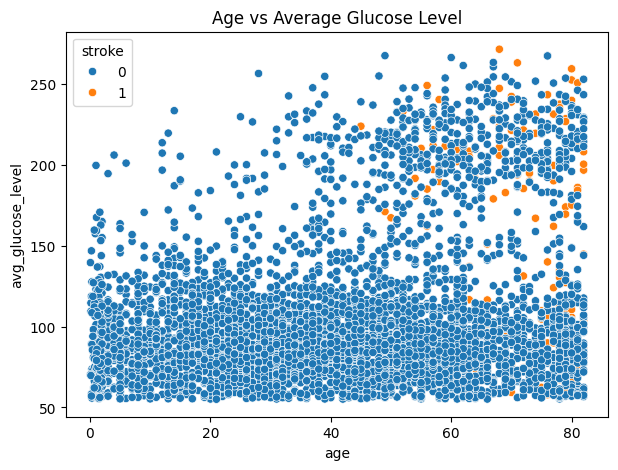

In [130]:
plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df,
    x="age",
    y="avg_glucose_level",
    hue="stroke"
)

plt.title("Age vs Average Glucose Level")
plt.show()

Bar Chart

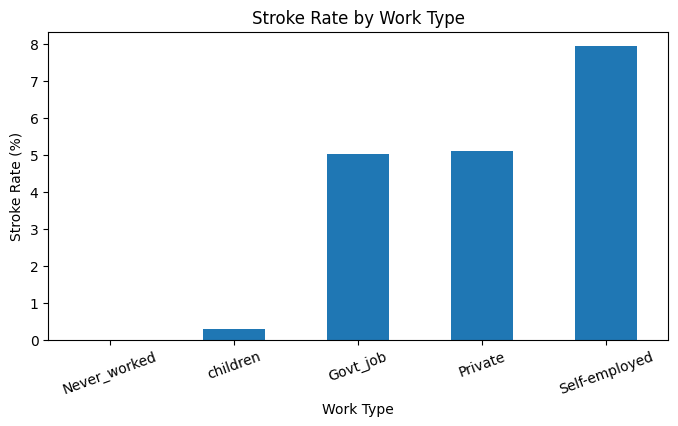

In [131]:
stroke_by_work = df.groupby("work_type")["stroke"].mean() * 100

plt.figure(figsize=(8, 4))

stroke_by_work.sort_values().plot(kind="bar")

plt.title("Stroke Rate by Work Type")
plt.xlabel("Work Type")
plt.ylabel("Stroke Rate (%)")
plt.xticks(rotation=20)
plt.show()

Correlation Heatmap

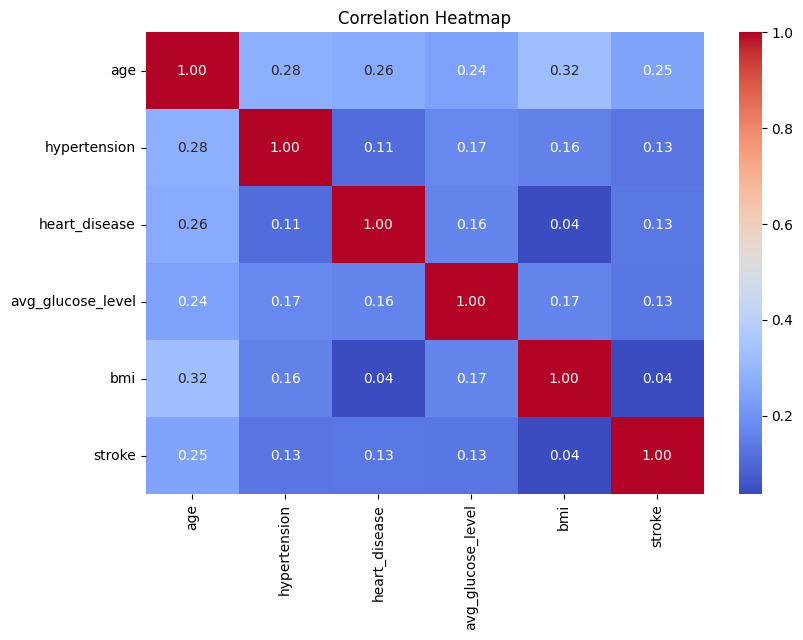

In [132]:
plt.figure(figsize=(9, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

Pair Plot

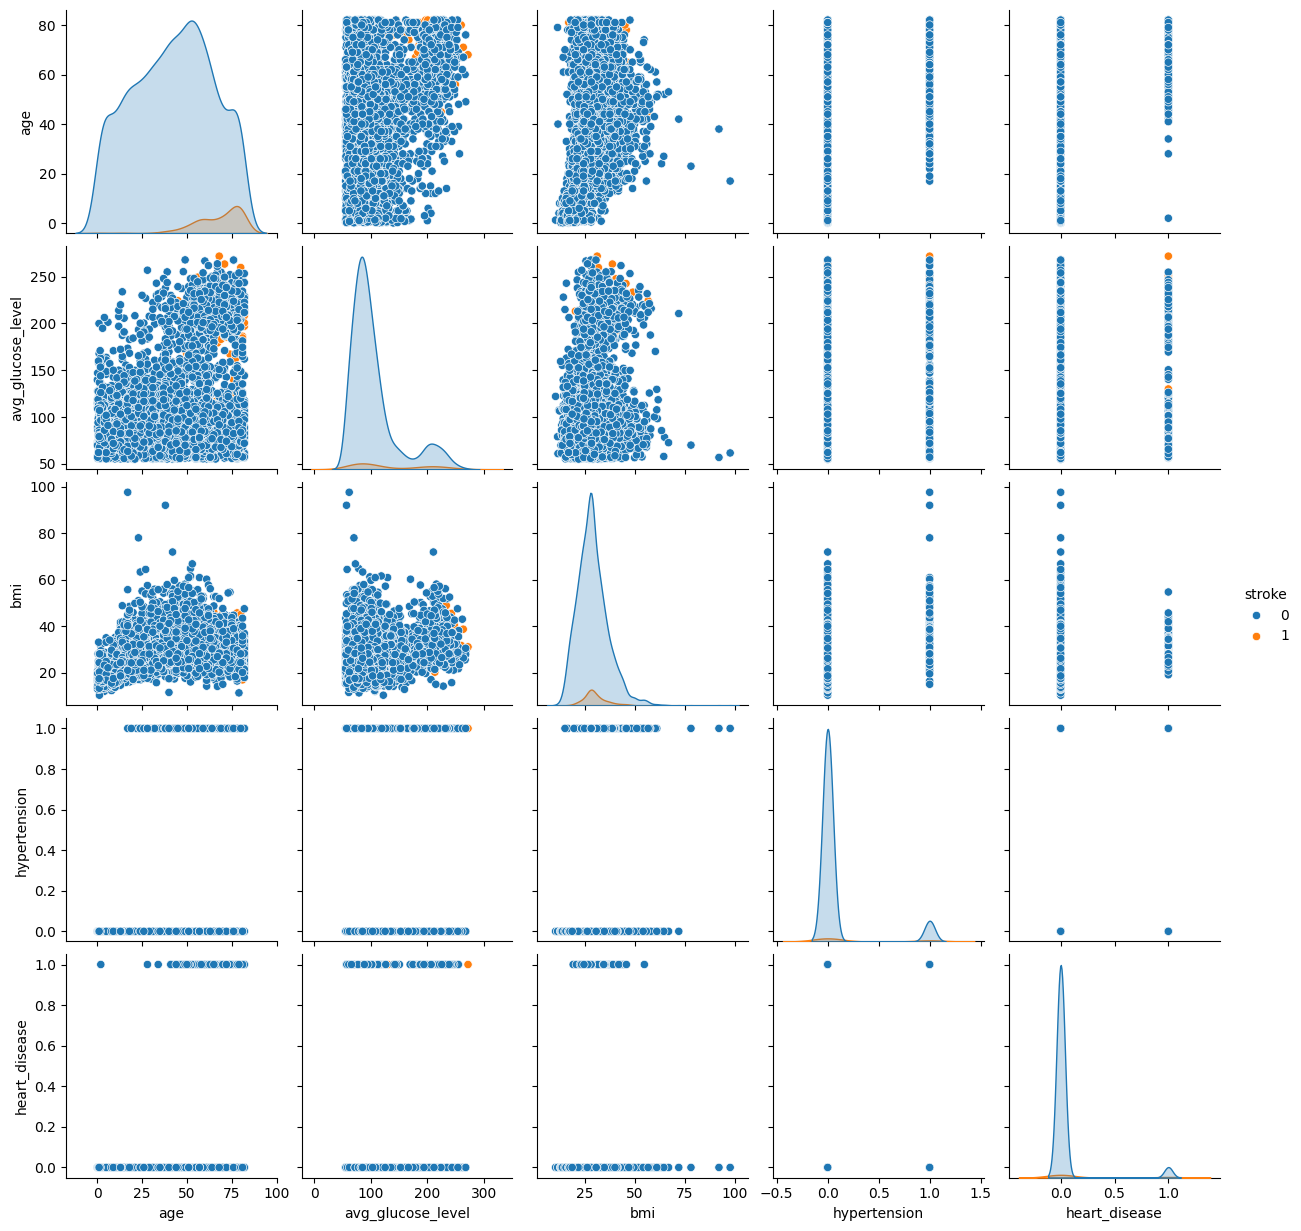

In [133]:
sns.pairplot(
    df[
        [
            "age",
            "avg_glucose_level",
            "bmi",
            "hypertension",
            "heart_disease",
            "stroke"
        ]
    ],
    hue="stroke"
)

plt.show()

# 10. Visual Storytelling

Chart 1 — Stroke Distribution  :

 - Business Question:


How common are stroke cases in the dataset?

 - Observation:


 - - Most patients did not experience a stroke, while a much smaller number experienced a stroke.

 - Interpretation:


 - - The target variable is highly imbalanced, with approximately 95.13% non-stroke cases and 4.87% stroke cases.

 - Business Insight:


 - - Healthcare analysis should pay particular attention to the smaller stroke group rather than relying only on the overall majority group.

Chart 2 — Age and Stroke  :



 - Business Question:


 - - Is stroke more common among older patients?

 - Observation:


 - - Stroke patients have a considerably higher average age.

 - Interpretation:


 - - The average age is approximately 67.73 for stroke patients compared with 41.97 for non-stroke patients.

 - Business Insight:


 - - Age should be considered an important factor when studying patients at higher risk of stroke.

Chart 3 — Glucose and Stroke  :

 - Business Question:


 - - How does average glucose level differ between stroke and non-stroke patients?

 - Observation:


 - - Stroke patients have a higher average glucose level.

 - Interpretation:


 - -The average glucose level is approximately 132.54 for stroke patients compared with 104.80 for non-stroke patients.

 - Business Insight:


 - - Glucose levels may be useful when identifying patient groups that require closer monitoring.

Chart 4 — Hypertension and Stroke  :

 - Business Question:
 - - Does stroke occurrence differ between patients with and without hypertension?

 - Observation:
 - - The stroke rate is higher among patients with hypertension.

 - Interpretation:
 - - The stroke rate is approximately 13.25% for patients with hypertension compared with 3.97% for patients without hypertension.

 - Business Insight:
 - - Patients with hypertension may require more attention in preventive healthcare programs.

Chart 5 — Heart Disease and Stroke  :

 - Business Question:


 - - How does heart disease relate to stroke occurrence?

 - Observation:


 - - Patients with heart disease have a higher stroke rate.

 - Interpretation:


 - - The stroke rate is approximately 17.03% among patients with heart disease compared with 4.18% among patients without heart disease.

 - Business Insight:


 - - Heart health should be considered together with other patient characteristics when studying stroke risk.

# 11. Business Insights

 Business Insights:

1. Stroke cases represent a small proportion of the total dataset. Around 4.87% of patients experienced a stroke, showing a strong class imbalance.

2. Age shows the strongest numerical relationship with stroke among the variables analyzed. Stroke patients have a much higher average age than non-stroke patients.

3. Average glucose level is higher among patients who experienced a stroke.

4. Hypertension is associated with a higher observed stroke rate. Patients with hypertension have an observed stroke rate of approximately 13.25%, compared with 3.97% for patients without hypertension.

5. Heart disease also shows a noticeable difference. The observed stroke rate is approximately 17.03% among patients with heart disease compared with 4.18% among patients without heart disease.

6. BMI has only a weak numerical relationship with stroke in this dataset.

7. Smoking status and work type show differences between groups, but these relationships should be interpreted carefully and should not be considered proof of direct cause.

8. Overall, age, glucose level, hypertension and heart disease appear to be important variables for further investigation.

 Recommendations:

1. Healthcare teams can give greater attention to older patients during stroke-risk assessment.

2. Patients with hypertension may benefit from regular monitoring and preventive care.

3. Patients with existing heart disease may require closer monitoring because the observed stroke rate is higher in this group.

4. Glucose levels can be included as one of the health indicators considered during patient assessment.

5. Since stroke cases are much fewer than non-stroke cases, future predictive analysis should account for the class imbalance.

6. The relationships identified in Sprint 2 should be investigated further using appropriate statistical methods in Sprint 3.

# Sprint 2 Deliverables

Save the EDA results/data

In [134]:
df.to_csv("stroke_sprint2_analysis_data.csv", index=False)

Save Group-Based Analysis

In [135]:
work_analysis.to_csv("group_based_analysis.csv")

Save Pivot Tables

In [136]:
pivot_gender.to_csv("pivot_gender_stroke.csv")
pivot_work.to_csv("pivot_work_stroke.csv")
pivot_smoking.to_csv("pivot_smoking_stroke.csv")
pivot_health.to_csv("pivot_health.csv")

Save Crosstab Reports

In [137]:
pd.crosstab(
    df["gender"],
    df["stroke"]
).to_csv("crosstab_gender_stroke.csv")

pd.crosstab(
    df["work_type"],
    df["stroke"]
).to_csv("crosstab_work_stroke.csv")

pd.crosstab(
    df["smoking_status"],
    df["stroke"]
).to_csv("crosstab_smoking_stroke.csv")

In [138]:
print("Sprint 2 Dataset Shape:", df.shape)
print(df.columns.tolist())

Sprint 2 Dataset Shape: (5110, 12)
['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke']


In [139]:
from google.colab import files

df.to_csv("stroke_data_sprint2_final.csv", index=False)

files.download("stroke_data_sprint2_final.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>